In [9]:
import pandas as pd
G_train = pd.read_csv("GoEmotions/Processed/GoEmotions_train.csv")
G_test = pd.read_csv("GoEmotions/Processed/GoEmotions_test.csv")

S_train = pd.read_csv("SemEvalDataset/processed/train.csv")
S_test = pd.read_csv("SemEvalDataset/processed/test.csv")

T_train = pd.read_csv("TwitterEmotions/training.csv")
T_test = pd.read_csv("TwitterEmotions/test.csv")

In [10]:
G_train = G_train.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})
G_test = G_test.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})

In [11]:
emotions = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

def parse_labels(label_str):
    return [int(x) for x in str(label_str).split(",")]

def make_multilabel_columns(df):
    df = df.copy()

    # Convert "13,18" into [13, 18]
    df["label_list"] = df["label_id"].apply(parse_labels)

    # Add readable labels: [13,18] -> ["excitement", "love"]
    df["label_names"] = df["label_list"].apply(
        lambda ids: [emotions[i] for i in ids]
    )

    # Create one binary column per emotion
    for i, emotion in enumerate(emotions):
        df[emotion] = df["label_list"].apply(lambda labels: 1 if i in labels else 0)

    return df

G_train = make_multilabel_columns(G_train)
G_test = make_multilabel_columns(G_test)

# print(goemotions_train[["label_id", "label_list", "label_names"]].head())

emotion_cols = emotions
print(G_train.columns)
print(G_test.columns)

Index(['text', 'label_id', 'example_id', 'label_list', 'label_names',
       'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')
Index(['text', 'label_id', 'example_id', 'label_list', 'label_names',
       'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')


# Go Emotions Analysis

## Emotion Density

In [12]:
print("Total samples in GoEmotions train:", len(G_train))
print("Total samples in GoEmotions test:", len(G_test))
print("Number of emotion columns:", 28)
labels_per_comment_train = G_train[emotion_cols].sum(axis=1)
labels_per_comment_test = G_test[emotion_cols].sum(axis=1)

print("Average labels per comment in GoEmotions train:",labels_per_comment_train.mean())
print("Average labels per comment in GoEmotions test:",labels_per_comment_test.mean())

multi_label_train = (labels_per_comment_train > 1).sum()
print("Multi-label samples in train data:", multi_label_train)
print("Percentage:", 100 * multi_label_train / len(G_train))

multi_label_test = (labels_per_comment_test > 1).sum()
print("Multi-label samples in train data:", multi_label_test)
print("Percentage:", 100 * multi_label_test / len(G_test))

Total samples in GoEmotions train: 43410
Total samples in GoEmotions test: 5427
Number of emotion columns: 28
Average labels per comment in GoEmotions train: 1.1772172310527529
Average labels per comment in GoEmotions test: 1.1662060070020268
Multi-label samples in train data: 7102
Percentage: 16.360285648468096
Multi-label samples in train data: 837
Percentage: 15.422885572139304


Emotion Frequency

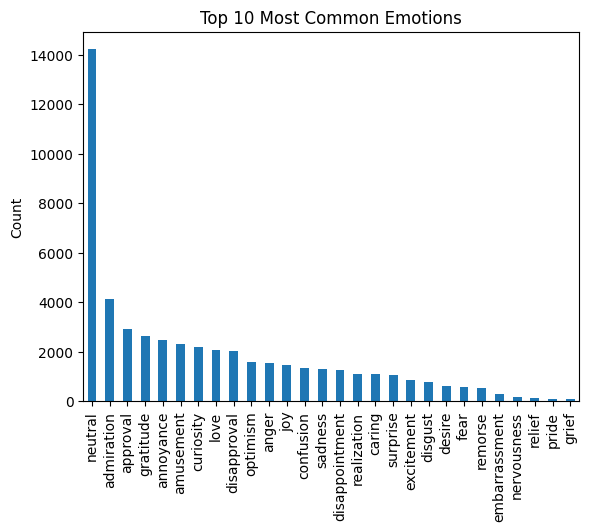

                Count  Percent
neutral         14219    27.82
admiration       4130     8.08
approval         2939     5.75
gratitude        2662     5.21
annoyance        2470     4.83
amusement        2328     4.56
curiosity        2191     4.29
love             2086     4.08
disapproval      2022     3.96
optimism         1581     3.09
anger            1567     3.07
joy              1452     2.84
confusion        1368     2.68
sadness          1326     2.59
disappointment   1269     2.48
realization      1110     2.17
caring           1087     2.13
surprise         1060     2.07
excitement        853     1.67
disgust           793     1.55
desire            641     1.25
fear              596     1.17
remorse           545     1.07
embarrassment     303     0.59
nervousness       164     0.32
relief            153     0.30
pride             111     0.22
grief              77     0.15


In [15]:
import matplotlib.pyplot as plt

emotion_counts = G_train[emotion_cols].sum().sort_values(ascending=False)

emotion_counts.plot(kind="bar")
plt.title("Top 10 Most Common Emotions")
plt.ylabel("Count")
plt.show()

emotion_percentages = (
    emotion_counts / emotion_counts.sum() * 100
).round(2)

summary = pd.DataFrame({
    "Count": emotion_counts,
    "Percent": emotion_percentages
})

print(summary)

## Emotion Co-occurance 

In [30]:
import numpy as np
co_matrix = G_train[emotion_cols].T.dot(G_train[emotion_cols])
co_matrix_plot = co_matrix.copy()

for emotion in emotion_cols:
    co_matrix_plot.loc[emotion, emotion] = 0

co_matrix = co_matrix_plot
print(co_matrix)

                admiration  amusement  anger  annoyance  approval  caring  \
admiration               0         84      5         25       246      31   
amusement               84          0     15         40        57       8   
anger                    5         15      0        269         8       9   
annoyance               25         40    269          0        37      13   
approval               246         57      8         37         0      65   
caring                  31          8      9         13        65       0   
confusion               24         24      8         24        20       1   
curiosity               65         48     11         45        36      15   
desire                  33         10      4         12        18      11   
disappointment          24         10     30        110        23      10   
disapproval             14         20     43        178        19      14   
disgust                 10          9     53         80        13       2   

           Emotion1        Emotion2  Count
14       admiration       gratitude    279
53            anger       annoyance    269
3        admiration        approval    246
147       confusion       curiosity    212
124        approval         neutral    202
17       admiration            love    192
84        annoyance     disapproval    178
222  disappointment         sadness    133
101       annoyance         neutral    132
16       admiration             joy    126
187       curiosity         neutral    118
83        annoyance  disappointment    110
241     disapproval         neutral    109
19       admiration        optimism    106
117        approval        optimism    100
167       confusion         neutral     98
26       admiration         neutral     94
139          caring        optimism     90
42        amusement             joy     90
276      excitement             joy     86


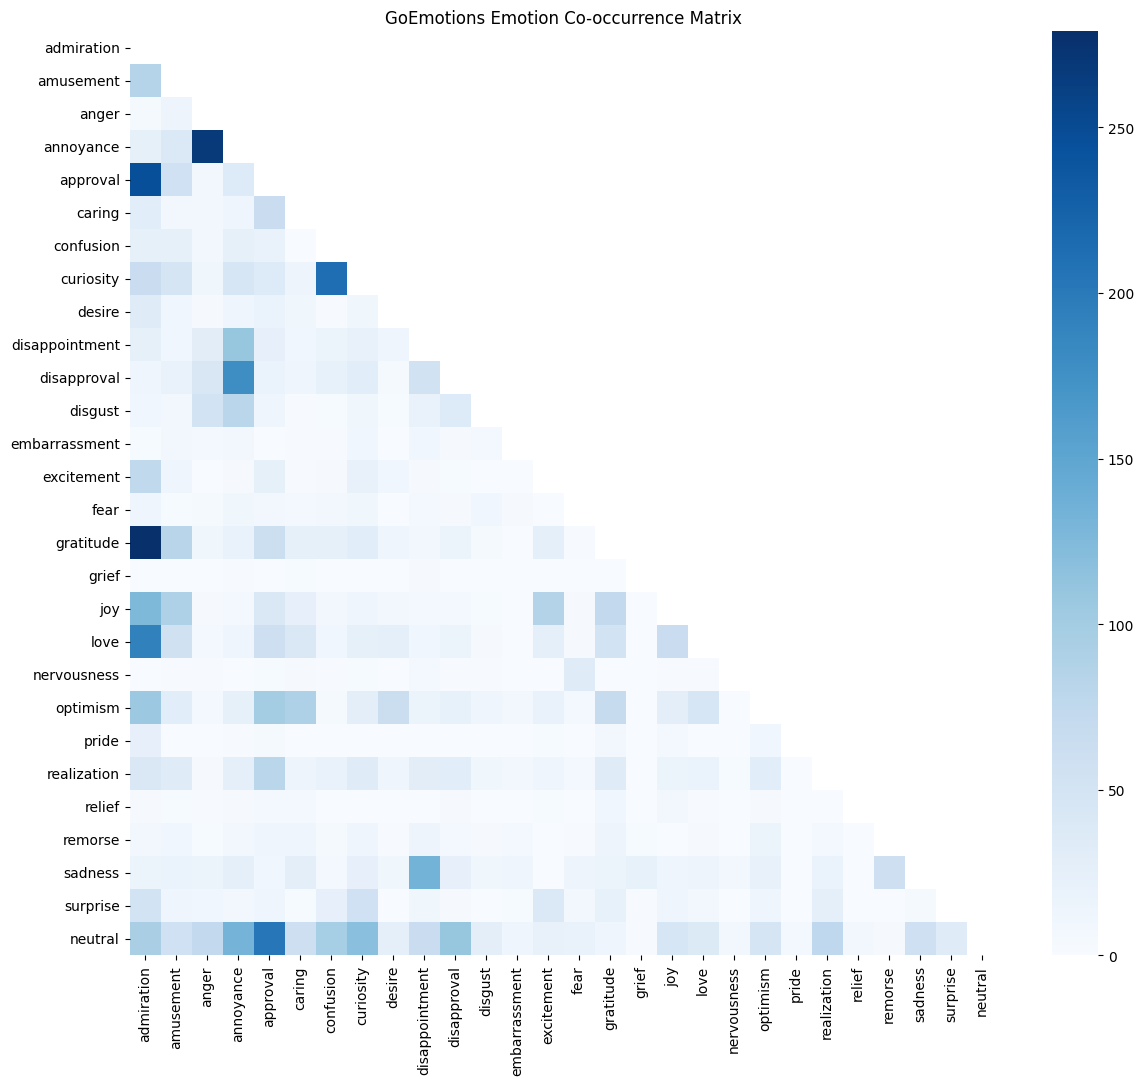

In [42]:
pairs = []

for i in range(len(emotion_cols)):
    for j in range(i+1, len(emotion_cols)):
        pairs.append(
            (
                emotion_cols[i],
                emotion_cols[j],
                co_matrix.iloc[i, j]
            )
        )

pairs_df = pd.DataFrame(
    pairs,
    columns=["Emotion1", "Emotion2", "Count"]
)

pairs_df = pairs_df.sort_values(
    "Count",
    ascending=False
)

print(pairs_df.head(20))

import seaborn as sns
import matplotlib.pyplot as plt

mask = np.triu(np.ones_like(co_matrix, dtype=bool))

plt.figure(figsize=(14,12))

sns.heatmap(
    co_matrix,
    mask=mask,
    cmap="Blues"
)

plt.title("GoEmotions Emotion Co-occurrence Matrix")
plt.show()

## Male vs Female

In [32]:
male_comments = G_train[
    G_train["text"].str.contains(
        r"\b(he|him|his)\b",
        case=False,
        regex=True,
        na=False
    )
]

female_comments = G_train[
    G_train["text"].str.contains(
        r"\b(she|her|hers)\b",
        case=False,
        regex=True,
        na=False
    )
]

print("Male comments:", len(male_comments))
print("Female comments:", len(female_comments))

Male comments: 4262
Female comments: 2195


/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/373901853.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_train["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/373901853.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_train["text"].str.contains(


In [37]:
male_emotions = male_comments[emotion_cols].sum().sort_values(ascending=False)

female_emotions = female_comments[emotion_cols].sum().sort_values(ascending=False)

male_pct = (
    male_comments[emotion_cols].sum()
    / len(male_comments)
    * 100
).sort_values(ascending=False)

female_pct = (
    female_comments[emotion_cols].sum()
    / len(female_comments)
    * 100
).sort_values(ascending=False)

comparison = pd.DataFrame({
    "Male %": male_pct,
    "Female %": female_pct
})

# Difference
Right now kind of hard to tell the difference so we can look more into that

                   Male %   Female %  Difference
sadness          2.932895   4.100228    1.167332
disgust          1.853590   2.733485    0.879895
gratitude        2.252464   3.097950    0.845486
admiration       9.784139  10.569476    0.785337
joy              2.064758   2.824601    0.759843
love             5.349601   5.876993    0.527392
embarrassment    0.539653   0.865604    0.325951
caring           2.651337   2.961276    0.309938
fear             1.173158   1.457859    0.284701
remorse          0.586579   0.820046    0.233466
surprise         2.627874   2.779043    0.151169
nervousness      0.305021   0.455581    0.150560
confusion        3.026748   3.143508    0.116760
relief           0.281558   0.364465    0.082907
annoyance        5.490380   5.558087    0.067706
excitement       0.938527   1.002278    0.063751
grief            0.351947   0.410023    0.058075
curiosity        5.114969   5.011390   -0.103580
realization      2.557485   2.414579   -0.142906
anger            3.4

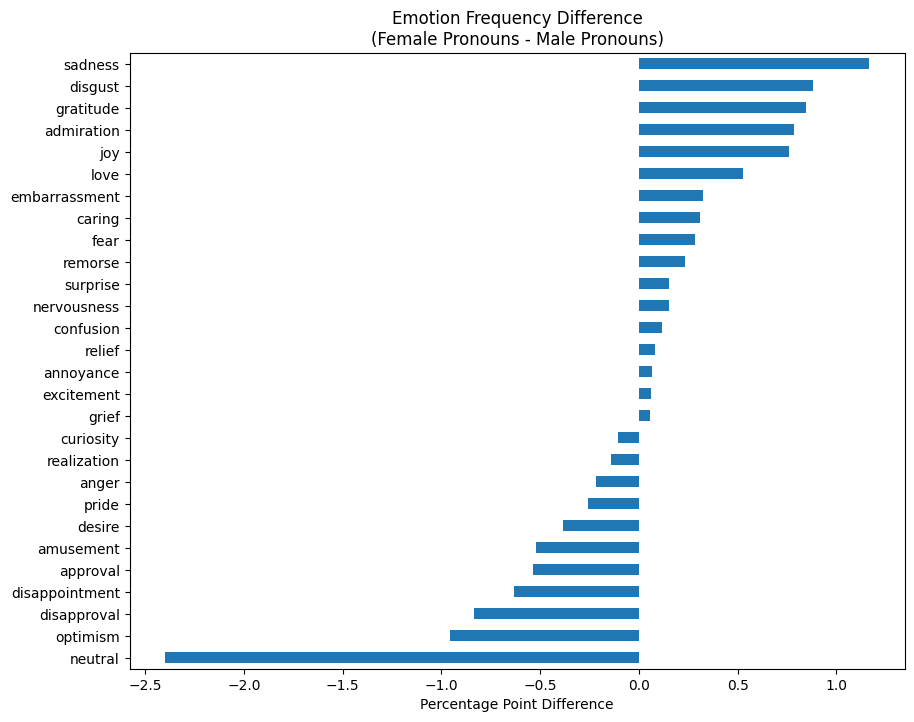

In [38]:
comparison["Difference"] = (
    comparison["Female %"]
    - comparison["Male %"]
)

comparison = comparison.sort_values(
    "Difference",
    ascending=False
)

print(comparison)

comparison["Difference"].sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Emotion Frequency Difference\n(Female Pronouns - Male Pronouns)")
plt.xlabel("Percentage Point Difference")
plt.show()